# Customer Retention: Repeat-Purchase Exploration

## Abstract

This notebook evaluates **90-day repeat-purchase classification** as a candidate analytics problem. Each row represents one customer, identified by `customer_unique_id`. Two decision points are explored: immediately after the first observed purchase and after the initial purchase occasion has been delivered. Only customers with a fully observable 90-day follow-up window receive a positive or negative target.

Repeat purchasing is rare: 2.12% of eligible customers repeat within 90 days of their first purchase, falling to 1.11% after delivery among customers who have not already returned. Basket size, product category and delivery experience show descriptive group differences, but individual numerical relationships are extremely weak: the largest absolute Spearman correlation is 0.033 at first purchase and 0.020 after delivery.

Retention is therefore a lower-priority candidate for this dataset. Olist lacks behavioural predictors such as browsing, abandoned baskets, campaign engagement, promotion exposure, loyalty activity and customer-service interactions; a first purchase also provides no earlier transaction history for recency or frequency features. A non-repeat label means only that no later order is observed within the chosen window, not permanent churn, and repeat propensity does not measure whether a campaign would change behaviour. If pursued, the candidate would require time-based cohort validation using precision–recall, calibration and lift rather than accuracy alone.

## 1. Analytical target

This section defines the customer-level outcome and the observation rules needed to avoid censoring.

- **Candidate:** classify whether a customer places another recorded order within 90 days.
- **Unit:** one `customer_unique_id`; the order-specific `customer_id` is not used as a person identifier.
- **Primary target:** `repeat_90d = 1` when a distinct purchase occasion occurs within 90 days after the first observed purchase.
- **Eligibility:** assign a zero only when the complete 90-day window is observable; otherwise leave the outcome unknown and exclude it.
- Orders sharing an identical timestamp form one purchase occasion and do not count as repeats.
- The target measures recorded order placement, including orders later cancelled or unavailable; it does not measure completed repeat purchases.
- Cohorts begin in January 2017, and the primary observation cutoff is 1 August 2018 (exclusive); alternative windows and a September cutoff are tested below.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.3f}".format)
DATA_DIR = Path("data") if Path("data").exists() else Path.cwd().parent / "data"
COHORT_START = pd.Timestamp("2017-01-01")
OBSERVATION_END = pd.Timestamp("2018-08-01")  # exclusive
HORIZON_DAYS = 90
BLUE, ORANGE = "#003D7C", "#EF7C00"

orders = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv", parse_dates=["order_purchase_timestamp"])
customers = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
items = pd.read_csv(DATA_DIR / "olist_order_items_dataset.csv")
products = pd.read_csv(DATA_DIR / "olist_products_dataset.csv")
sellers = pd.read_csv(DATA_DIR / "olist_sellers_dataset.csv")
translations = pd.read_csv(DATA_DIR / "product_category_name_translation.csv")

assert orders["order_id"].is_unique
assert customers["customer_id"].is_unique
assert products["product_id"].is_unique and sellers["seller_id"].is_unique
assert not items.duplicated(["order_id", "order_item_id"]).any()
assert orders["customer_id"].isin(customers["customer_id"]).all()
assert items["order_id"].isin(orders["order_id"]).all()
assert items["product_id"].isin(products["product_id"]).all()
assert items["seller_id"].isin(sellers["seller_id"]).all()
order_history = orders.merge(customers, on="customer_id", validate="many_to_one")
assert order_history[["customer_unique_id", "order_purchase_timestamp"]].notna().all().all()
order_history = order_history.sort_values(["customer_unique_id", "order_purchase_timestamp", "order_id"])
print(f"{len(order_history):,} orders; {order_history['customer_unique_id'].nunique():,} customers.")


99,441 orders; 96,096 customers.


## 2. Source coverage and overview baseline

This section distinguishes the descriptive overview statistic from the fixed-window target.

- The overview's 3.05% rate counts customers with multiple order IDs across the full consolidated dataset.
- Retention target construction uses raw orders so that cancelled or unavailable orders without item records are not silently omitted.
- The two rates are not interchangeable: they use different populations, follow-up rules and treatment of simultaneous orders.
- Order-status and end-of-dataset checks support the conservative 1 August 2018 observation cutoff.

,Population,Customers,Customers with multiple order IDs,Full-period repeat-customer rate (%)
0,Consolidated dataset,95420,2913,3.053
1,Raw orders,96096,2997,3.119


,orders
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


order_status,approved,canceled,created,delivered,invoiced,processing,shipped,unavailable
month,,,,,,,,
2018-05,0,24,0,6749,24,6,54,16
2018-06,0,18,0,6099,3,0,43,4
2018-07,0,41,0,6159,13,1,60,18
2018-08,0,84,0,6351,23,0,47,7
2018-09,0,15,0,0,0,0,1,0
2018-10,0,4,0,0,0,0,0,0


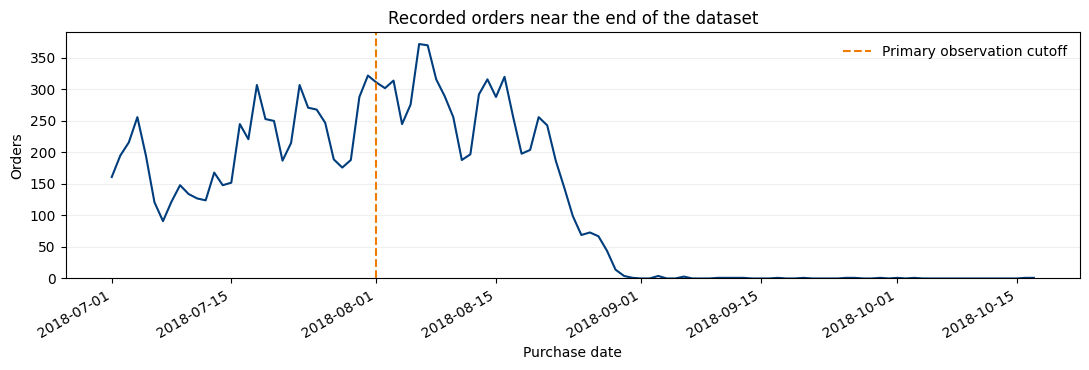

In [2]:
core = pd.read_csv(DATA_DIR / "smartcommerce_consolidated.csv", usecols=["order_id", "customer_id"])
core_customers = core.drop_duplicates("order_id").merge(
    customers[["customer_id", "customer_unique_id"]], on="customer_id", validate="many_to_one"
)
overview_counts = core_customers.groupby("customer_unique_id")["order_id"].nunique()
raw_counts = order_history.groupby("customer_unique_id")["order_id"].nunique()
display(pd.DataFrame({
    "Population": ["Consolidated dataset", "Raw orders"],
    "Customers": [len(overview_counts), len(raw_counts)],
    "Customers with multiple order IDs": [overview_counts.gt(1).sum(), raw_counts.gt(1).sum()],
    "Full-period repeat-customer rate (%)": [overview_counts.gt(1).mean()*100, raw_counts.gt(1).mean()*100],
}))
display(order_history.groupby("order_status").agg(orders=("order_id", "size")).sort_values("orders", ascending=False))
monthly_coverage = order_history.assign(month=order_history["order_purchase_timestamp"].dt.to_period("M")).groupby(
    ["month", "order_status"]
).size().unstack(fill_value=0)
display(monthly_coverage.tail(6))
daily_tail = order_history.loc[order_history["order_purchase_timestamp"].ge("2018-07-01")].groupby(
    order_history["order_purchase_timestamp"].dt.normalize()
).size()
daily_tail = daily_tail.reindex(pd.date_range("2018-07-01", order_history["order_purchase_timestamp"].max().normalize()), fill_value=0)
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(daily_tail.index, daily_tail.values, color=BLUE)
ax.axvline(OBSERVATION_END, color=ORANGE, linestyle="--", label="Primary observation cutoff")
ax.set(title="Recorded orders near the end of the dataset", xlabel="Purchase date", ylabel="Orders", ylim=(0, None))
ax.legend(frameon=False)
ax.grid(axis="y", alpha=.2)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## 3. Customer-level target construction

This section creates an unbiased fixed-window outcome for each eligible customer.

- Identify the first and next distinct purchase occasions from timestamp-sorted raw orders.
- Ignore events after the observation cutoff when assigning outcomes.
- Require complete follow-up for both repeaters and non-repeaters, preventing recent customers who repeat quickly from being selectively retained.
- **Primary result:** 1,514 of 71,397 eligible customers repeat within 90 days (2.12%).

In [3]:
events = order_history[["customer_unique_id", "order_purchase_timestamp"]].drop_duplicates().copy()
events["occasion_number"] = events.groupby("customer_unique_id").cumcount()
first_times = events.loc[events["occasion_number"].eq(0)].set_index("customer_unique_id")["order_purchase_timestamp"]
next_times = events.loc[events["occasion_number"].eq(1)].set_index("customer_unique_id")["order_purchase_timestamp"]
customer_targets = first_times.rename("first_purchase_at").to_frame().join(next_times.rename("next_purchase_at"))
customer_targets["days_to_next_purchase"] = (
    customer_targets["next_purchase_at"] - customer_targets["first_purchase_at"]
).dt.total_seconds() / 86400

def label_customers(horizon_days, observation_end):
    labelled = customer_targets.copy()
    labelled["window_end"] = labelled["first_purchase_at"] + pd.Timedelta(days=horizon_days)
    labelled["in_cohort"] = labelled["first_purchase_at"].ge(COHORT_START) & labelled["first_purchase_at"].lt(observation_end)
    labelled["full_followup"] = labelled["window_end"].lt(observation_end)
    labelled["eligible"] = labelled["in_cohort"] & labelled["full_followup"]
    repeated = (
        labelled["next_purchase_at"].gt(labelled["first_purchase_at"])
        & labelled["next_purchase_at"].le(labelled["window_end"])
        & labelled["next_purchase_at"].lt(observation_end)
    )
    labelled["repeat_target"] = repeated.astype("Int64").where(labelled["eligible"])
    return labelled

labelled = label_customers(HORIZON_DAYS, OBSERVATION_END)
target_population = labelled.loc[labelled["eligible"]].rename(columns={"repeat_target": "repeat_90d"})
assert target_population.index.is_unique
assert target_population["repeat_90d"].notna().all()
assert labelled.loc[~labelled["eligible"], "repeat_target"].isna().all()
assert target_population["window_end"].lt(OBSERVATION_END).all()
assert target_population.loc[target_population["repeat_90d"].eq(1), "days_to_next_purchase"].between(0, 90, inclusive="right").all()
display(pd.DataFrame({
    "Measure": ["Eligible customers", "Repeat within 90 days", "No observed repeat within 90 days",
                "Cohort customers excluded for insufficient follow-up", "90-day repeat rate (%)",
                "Extra orders at duplicate customer timestamps (full source)"],
    "Value": [len(target_population), target_population["repeat_90d"].sum(),
              target_population["repeat_90d"].eq(0).sum(),
              (labelled["in_cohort"] & ~labelled["full_followup"]).sum(),
              target_population["repeat_90d"].mean()*100, len(order_history)-len(events)],
}))


,Measure,Value
0,Eligible customers,71397.000
1,Repeat within 90 days,1514.000
2,No observed repeat within 90 days,69883.000
3,Cohort customers excluded for insufficient fol...,18096.000
4,90-day repeat rate (%),2.121
5,Extra orders at duplicate customer timestamps ...,292.000


## 4. Target sensitivity and cohort patterns

This section tests whether the rare repeat rate is an artefact of the chosen window or dataset cutoff.

- Compare 30-, 60-, 90- and 180-day horizons using both each window's eligible population and one common customer population.
- Compare August and September observation cutoffs to assess sensitivity to the uncertain dataset tail.
- Plot monthly first-purchase cohorts with 95% Wilson intervals; only cohorts with complete follow-up are included.
- **Main result:** repeat purchasing remains uncommon across reasonable definitions; the 90-day rate is approximately 2.1%.

,Observation end (exclusive),Window (days),Eligible customers,Repeats,Repeat rate (%),Common-population rate (%)
0,2018-08-01,30,83578,1143,1.368,1.501
1,2018-08-01,60,77658,1403,1.807,1.882
2,2018-08-01,90,71397,1514,2.121,2.167
3,2018-08-01,180,50953,1438,2.822,2.822
4,2018-09-01,30,89792,1217,1.355,1.501
5,2018-09-01,60,83768,1461,1.744,1.882
6,2018-09-01,90,77799,1610,2.069,2.167
7,2018-09-01,180,58139,1673,2.878,2.822


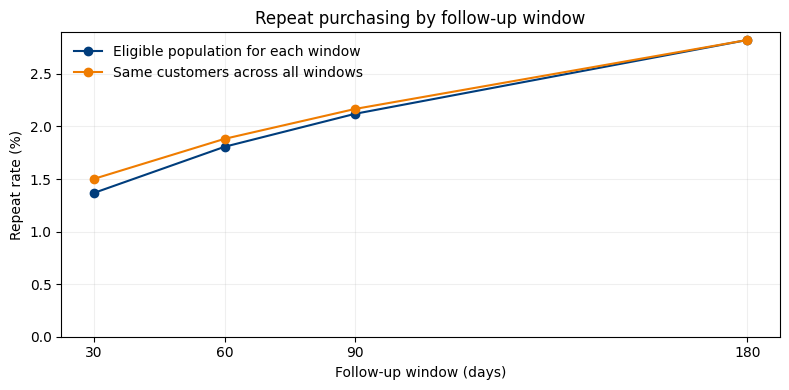

,Repeat definition,Customers,Rate (%)
0,Any strictly later purchase within 90 days,1514,2.121
1,"Purchase more than 24 hours later, within 90 days",932,1.305


In [4]:
sensitivity_rows = []
common_ids = label_customers(180, OBSERVATION_END).query("eligible").index
for end in [OBSERVATION_END, pd.Timestamp("2018-09-01")]:
    for horizon in [30, 60, 90, 180]:
        result = label_customers(horizon, end)
        valid = result.loc[result["eligible"]]
        sensitivity_rows.append({
            "Observation end (exclusive)": end.date(), "Window (days)": horizon,
            "Eligible customers": len(valid), "Repeats": int(valid["repeat_target"].sum()),
            "Repeat rate (%)": valid["repeat_target"].mean()*100,
            "Common-population rate (%)": result.loc[common_ids, "repeat_target"].mean()*100,
        })
window_sensitivity = pd.DataFrame(sensitivity_rows)
display(window_sensitivity)
primary_windows = window_sensitivity.loc[window_sensitivity["Observation end (exclusive)"].eq(OBSERVATION_END.date())]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(primary_windows["Window (days)"], primary_windows["Repeat rate (%)"], marker="o", color=BLUE, label="Eligible population for each window")
ax.plot(primary_windows["Window (days)"], primary_windows["Common-population rate (%)"], marker="o", color=ORANGE, label="Same customers across all windows")
ax.set(xlabel="Follow-up window (days)", ylabel="Repeat rate (%)", title="Repeat purchasing by follow-up window", ylim=(0, None))
ax.set_xticks([30, 60, 90, 180])
ax.legend(frameon=False)
ax.grid(alpha=.2)
plt.tight_layout()
plt.show()

# A later purchase beyond 24 hours is counted even if another order occurred earlier.
event_gaps = events.merge(first_times.rename("first_purchase_at"), on="customer_unique_id", validate="many_to_one")
event_gaps["gap_days"] = (event_gaps["order_purchase_timestamp"]-event_gaps["first_purchase_at"]).dt.total_seconds()/86400
later_than_day_one = set(event_gaps.loc[
    event_gaps["gap_days"].gt(1) & event_gaps["gap_days"].le(HORIZON_DAYS)
    & event_gaps["order_purchase_timestamp"].lt(OBSERVATION_END), "customer_unique_id"
])
display(pd.DataFrame({
    "Repeat definition": ["Any strictly later purchase within 90 days", "Purchase more than 24 hours later, within 90 days"],
    "Customers": [int(target_population["repeat_90d"].sum()), int(target_population.index.isin(later_than_day_one).sum())],
    "Rate (%)": [target_population["repeat_90d"].mean()*100, target_population.index.isin(later_than_day_one).mean()*100],
}))


,customers,repeats,repeat_rate_pct,lower_pct,upper_pct
first_month,,,,,
2017-01,764,24,3.141,2.120,4.632
2017-02,1752,28,1.598,1.108,2.300
2017-03,2636,61,2.314,1.806,2.961
2017-04,2352,44,1.871,1.397,2.502
2017-05,3596,93,2.586,2.116,3.158
2017-06,3139,84,2.676,2.167,3.301
2017-07,3894,88,2.260,1.838,2.776
2017-08,4184,102,2.438,2.012,2.951
2017-09,4130,105,2.542,2.105,3.068


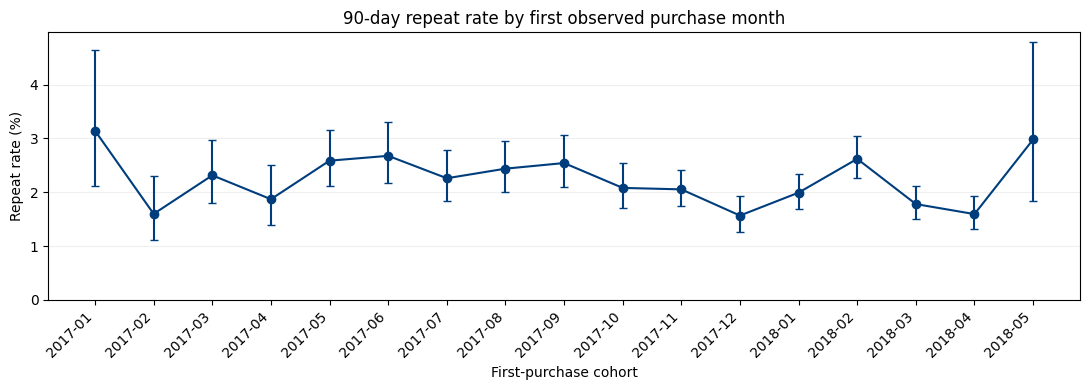

In [5]:
def rate_summary(frame, group):
    result = frame.groupby(group, observed=True)["repeat_90d"].agg(customers="size", repeats="sum")
    result["repeats"] = result["repeats"].astype(int)
    n = result["customers"].astype(float)
    p = result["repeats"] / n
    z = 1.96
    centre = (p + z*z/(2*n)) / (1 + z*z/n)
    half = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / (1 + z*z/n)
    result["repeat_rate_pct"] = 100*p
    result["lower_pct"] = 100*(centre-half)
    result["upper_pct"] = 100*(centre+half)
    return result

cohort_data = target_population.copy()
cohort_data["first_month"] = cohort_data["first_purchase_at"].dt.to_period("M")
cohort_rates = rate_summary(cohort_data, "first_month")
display(cohort_rates)
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(cohort_rates))
ax.errorbar(x, cohort_rates["repeat_rate_pct"], yerr=[
    cohort_rates["repeat_rate_pct"]-cohort_rates["lower_pct"],
    cohort_rates["upper_pct"]-cohort_rates["repeat_rate_pct"],
], fmt="o-", color=BLUE, capsize=3)
ax.set_xticks(x, cohort_rates.index.astype(str), rotation=45, ha="right")
ax.set(title="90-day repeat rate by first observed purchase month", xlabel="First-purchase cohort", ylabel="Repeat rate (%)", ylim=(0, None))
ax.grid(axis="y", alpha=.2)
plt.tight_layout()
plt.show()


## 5. First-purchase feature construction

This section creates predictors associated with the customer's initial purchase occasion.

- Combine simultaneous first-order IDs before aggregating basket value, freight, item and seller counts, product characteristics, geography and purchase timing.
- Aggregate item and product data before joining to the customer-level target.
- Preserve missing metadata as missing; do not interpret an absent item record as a zero-value basket.
- Exclude delivery outcomes, reviews, final status, later purchases and full-history totals because they occur later or may contain future information.
- Defer payment variables because their exact availability at the proposed decision point is not established.

In [6]:
first_orders = order_history.merge(first_times.rename("first_purchase_at"), on="customer_unique_id", validate="many_to_one")
first_orders = first_orders.loc[first_orders["order_purchase_timestamp"].eq(first_orders["first_purchase_at"])].copy()
first_order_counts = first_orders.groupby("customer_unique_id").size().rename("initial_order_count")
first_items = (
    first_orders[["customer_unique_id", "order_id", "customer_state"]]
    .merge(items, on="order_id", how="inner", validate="one_to_many")
    .merge(products[["product_id", "product_category_name", "product_weight_g"]], on="product_id", validate="many_to_one")
    .merge(sellers[["seller_id", "seller_state"]], on="seller_id", validate="many_to_one")
    .merge(translations, on="product_category_name", how="left", validate="many_to_one")
)
first_items["category"] = first_items["product_category_name_english"].fillna("Unknown")
first_items["same_state"] = first_items["customer_state"].eq(first_items["seller_state"])
first_items["unknown_category"] = first_items["category"].eq("Unknown")
first_features = first_items.groupby("customer_unique_id").agg(
    first_product_value=("price", "sum"), first_freight=("freight_value", "sum"),
    first_item_count=("order_item_id", "size"), first_product_count=("product_id", "nunique"),
    first_seller_count=("seller_id", "nunique"), first_category_count=("category", "nunique"),
    mean_item_weight_g=("product_weight_g", "mean"),
    same_state_item_share=("same_state", "mean"), unknown_category_share=("unknown_category", "mean"),
)
first_features["first_basket_total"] = first_features["first_product_value"] + first_features["first_freight"]
first_features["freight_share"] = first_features["first_freight"] / first_features["first_basket_total"].replace(0, np.nan)
dominant_category = (
    first_items.groupby(["customer_unique_id", "category"], as_index=False)["price"].sum()
    .sort_values(["customer_unique_id", "price", "category"], ascending=[True, False, True])
    .drop_duplicates("customer_unique_id").set_index("customer_unique_id")["category"].rename("dominant_category")
)
first_states = first_orders.groupby("customer_unique_id")["customer_state"].agg(
    lambda values: values.iloc[0] if values.nunique()==1 else "Multiple"
)
features = first_times.rename("first_purchase_at").to_frame().join(
    [first_order_counts, first_states, first_features, dominant_category], validate="one_to_one"
)
features["has_item_records"] = features["first_item_count"].notna().astype(int)
features["dominant_category"] = features["dominant_category"].fillna("No item record")
features["purchase_hour"] = features["first_purchase_at"].dt.hour
features["purchase_weekday"] = features["first_purchase_at"].dt.dayofweek
features["purchase_month"] = features["first_purchase_at"].dt.month
features["purchase_weekend"] = features["purchase_weekday"].ge(5).astype(int)
analysis = features.join(target_population[["repeat_90d"]], how="inner", validate="one_to_one")
assert len(analysis)==len(target_population) and analysis.index.is_unique
assert analysis["repeat_90d"].notna().all()
display(analysis.drop(columns="first_purchase_at").isna().sum().rename("Missing customers").to_frame())
print(f"Feature table: {len(analysis):,} customers; {analysis['repeat_90d'].sum():,} positive outcomes.")


,Missing customers
initial_order_count,0
customer_state,0
first_product_value,606
first_freight,606
first_item_count,606
first_product_count,606
first_seller_count,606
first_category_count,606
mean_item_weight_g,620
same_state_item_share,606


Feature table: 71,397 customers; 1,514 positive outcomes.


## 6. First-purchase feature relationships

This section screens for useful relationships between initial-purchase information and 90-day repeat purchasing.

- **Numerical method:** Spearman correlation using complete feature–target pairs, with missingness reported separately.
- **Group method:** repeat rates, sample sizes and 95% Wilson intervals across basket, category and geography groups.
- **Main result:** all individual numerical relationships are extremely weak; the largest absolute correlation is 0.033.
- Larger first baskets and some categories show descriptive differences, but overlapping factors are not isolated.
- Results are exploratory associations, not causal effects or out-of-sample predictive performance.

,Feature,Customers,Repeats,Missing (%),Spearman rho
5,first_product_count,70791,1492,0.849,0.033
4,first_item_count,70791,1492,0.849,0.024
6,first_seller_count,70791,1492,0.849,0.022
7,first_category_count,70791,1492,0.849,0.020
0,initial_order_count,71397,1514,0.000,0.014
9,freight_share,70791,1492,0.849,0.013
1,first_product_value,70791,1492,0.849,-0.010
12,has_item_records,71397,1514,0.000,-0.010
3,first_basket_total,70791,1492,0.849,-0.009
8,mean_item_weight_g,70777,1492,0.868,-0.007


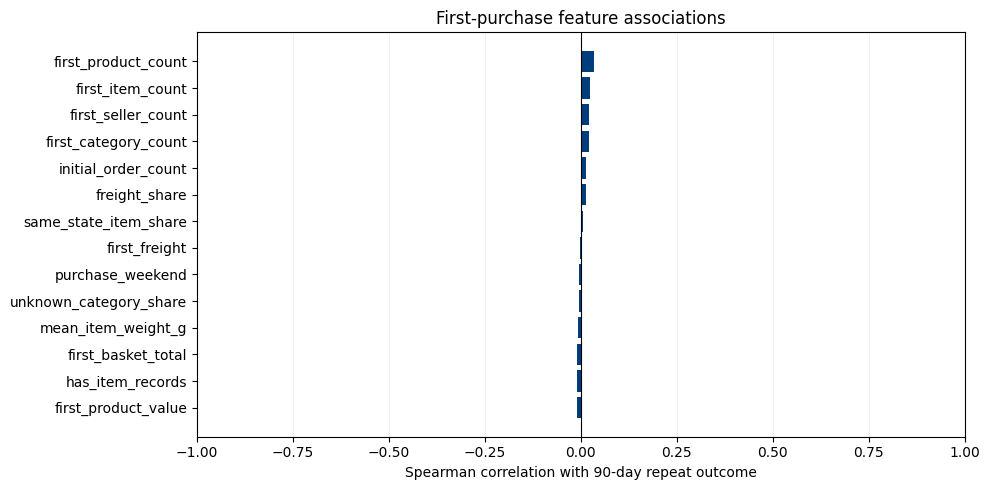

In [7]:
numeric_features = [
    "initial_order_count", "first_product_value", "first_freight", "first_basket_total",
    "first_item_count", "first_product_count", "first_seller_count", "first_category_count",
    "mean_item_weight_g", "freight_share", "same_state_item_share", "unknown_category_share",
    "has_item_records", "purchase_weekend",
]
association_rows = []
for feature in numeric_features:
    pairs = analysis[[feature, "repeat_90d"]].dropna().astype(float)
    rho = pairs.rank().corr().iloc[0, 1] if pairs[feature].nunique()>1 else np.nan
    association_rows.append({
        "Feature": feature, "Customers": len(pairs), "Repeats": int(pairs["repeat_90d"].sum()),
        "Missing (%)": analysis[feature].isna().mean()*100, "Spearman rho": rho,
    })
associations = pd.DataFrame(association_rows)
associations["absolute_rho"] = associations["Spearman rho"].abs()
associations = associations.sort_values("absolute_rho", ascending=False).drop(columns="absolute_rho")
display(associations)
plot_associations = associations.dropna(subset=["Spearman rho"]).sort_values("Spearman rho")
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(plot_associations["Feature"], plot_associations["Spearman rho"], color=BLUE)
ax.axvline(0, color="black", linewidth=.8)
ax.set(xlabel="Spearman correlation with 90-day repeat outcome", title="First-purchase feature associations", xlim=(-1, 1))
ax.grid(axis="x", alpha=.2)
plt.tight_layout()
plt.show()


,customers,repeats,repeat_rate_pct,lower_pct,upper_pct
basket_value_band,,,,,
"(0.849, 45.9]",17710,388,2.191,1.985,2.417
"(45.9, 86.99]",17714,402,2.269,2.060,2.499
"(86.99, 149.99]",17872,369,2.065,1.866,2.284
"(149.99, 13440.0]",17495,333,1.903,1.711,2.117


,customers,repeats,repeat_rate_pct,lower_pct,upper_pct
freight_share_band,,,,,
"(-0.001, 0.116]",17698,331,1.870,1.681,2.081
"(0.116, 0.182]",17709,373,2.106,1.905,2.328
"(0.182, 0.273]",17686,368,2.081,1.881,2.302
"(0.273, 0.955]",17698,420,2.373,2.159,2.608


,customers,repeats,repeat_rate_pct,lower_pct,upper_pct
basket_size_band,,,,,
1 item,63637,1268,1.993,1.887,2.104
2 items,5520,160,2.899,2.488,3.375
3+ items,1634,64,3.917,3.079,4.971


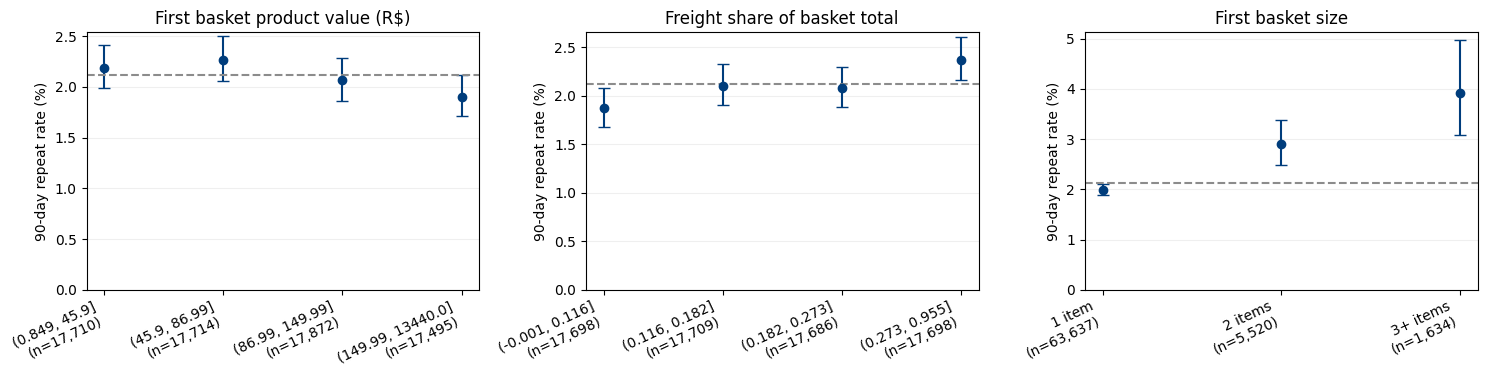

,customers,repeats,repeat_rate_pct,lower_pct,upper_pct
dominant_category,,,,,
bed_bath_table,6716,246,3.663,3.239,4.139
sports_leisure,5786,151,2.610,2.229,3.053
health_beauty,5688,116,2.039,1.703,2.440
computers_accessories,4982,100,2.007,1.653,2.435
furniture_decor,4641,145,3.124,2.661,3.665
housewares,3748,63,1.681,1.316,2.145
watches_gifts,3627,59,1.627,1.263,2.093
telephony,3227,48,1.487,1.124,1.967
toys,3076,51,1.658,1.263,2.173


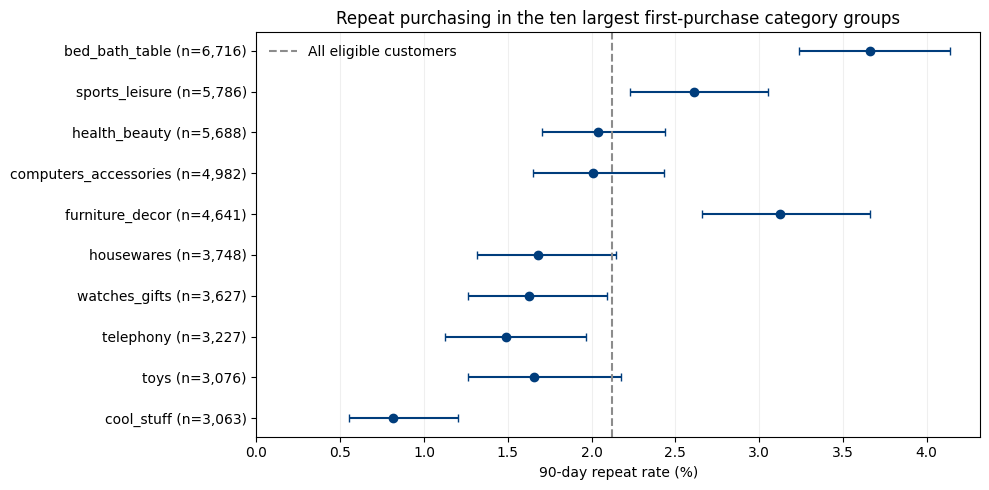

,customers,repeats,repeat_rate_pct,lower_pct,upper_pct
customer_state,,,,,
SP,28852,642,2.225,2.061,2.402
RJ,9499,214,2.253,1.973,2.571
MG,8528,167,1.958,1.685,2.275
RS,4070,91,2.236,1.825,2.737
PR,3665,77,2.101,1.684,2.618
SC,2725,45,1.651,1.236,2.202
BA,2467,45,1.824,1.366,2.432
GO,1500,27,1.800,1.240,2.606
ES,1495,35,2.341,1.688,3.238


In [8]:
# Identical values stay together; qcut drops duplicate boundaries where necessary.
analysis["basket_value_band"] = pd.qcut(analysis["first_product_value"], q=4, duplicates="drop")
analysis["freight_share_band"] = pd.qcut(analysis["freight_share"], q=4, duplicates="drop")
analysis["basket_size_band"] = pd.cut(
    analysis["first_item_count"], bins=[0, 1, 2, np.inf], labels=["1 item", "2 items", "3+ items"]
)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, group, title in zip(
    axes, ["basket_value_band", "freight_share_band", "basket_size_band"],
    ["First basket product value (R$)", "Freight share of basket total", "First basket size"]
):
    summary = rate_summary(analysis, group)
    display(summary)
    positions = np.arange(len(summary))
    ax.errorbar(positions, summary["repeat_rate_pct"], yerr=[
        summary["repeat_rate_pct"]-summary["lower_pct"], summary["upper_pct"]-summary["repeat_rate_pct"]
    ], fmt="o", color=BLUE, capsize=4)
    ax.axhline(analysis["repeat_90d"].mean()*100, color="#8C8C8C", linestyle="--")
    ax.set_xticks(positions, [f"{label}\n(n={n:,})" for label, n in zip(summary.index.astype(str), summary["customers"])], rotation=25, ha="right")
    ax.set(title=title, ylabel="90-day repeat rate (%)", ylim=(0, None))
    ax.grid(axis="y", alpha=.2)
plt.tight_layout()
plt.show()

category_rates = rate_summary(analysis, "dominant_category").sort_values("customers", ascending=False)
display(category_rates.head(10))
top_categories = category_rates.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 5))
positions = np.arange(len(top_categories))
ax.errorbar(top_categories["repeat_rate_pct"], positions, xerr=[
    top_categories["repeat_rate_pct"]-top_categories["lower_pct"],
    top_categories["upper_pct"]-top_categories["repeat_rate_pct"]
], fmt="o", color=BLUE, capsize=3)
ax.set_yticks(positions, [f"{label} (n={n:,})" for label, n in zip(top_categories.index, top_categories["customers"])])
ax.axvline(analysis["repeat_90d"].mean()*100, color="#8C8C8C", linestyle="--", label="All eligible customers")
ax.set(xlabel="90-day repeat rate (%)", title="Repeat purchasing in the ten largest first-purchase category groups", xlim=(0, None))
ax.legend(frameon=False)
ax.grid(axis="x", alpha=.2)
plt.tight_layout()
plt.show()
display(rate_summary(analysis, "customer_state").sort_values("customers", ascending=False).head(10))


**Reading the group charts:** error bars are 95% Wilson intervals and dashed lines show the overall eligible-customer rate. Category, geography and basket differences may overlap, so the charts do not isolate individual effects.

## 7. Alternative decision point: after first delivery

This section tests whether waiting until delivery provides a more useful retention target.

- Start the 90-day window when every order in the initial purchase occasion has been delivered.
- Exclude customers who already repeated by that point, incomplete deliveries and customers without full follow-up.
- Use delivered status only to establish the decision milestone, not as a predictor.
- **Result:** 727 of 65,470 eligible customers repeat in the following 90 days (1.11%).
- The first-purchase and post-delivery rates use different starting points and populations and are not a treatment comparison.

In [9]:
delivery_source = pd.read_csv(
    DATA_DIR / "olist_orders_dataset.csv",
    parse_dates=["order_delivered_customer_date", "order_estimated_delivery_date"],
)
first_delivery_orders = first_orders[["customer_unique_id", "order_id", "first_purchase_at"]].merge(
    delivery_source[["order_id", "order_status", "order_delivered_customer_date", "order_estimated_delivery_date"]],
    on="order_id", validate="one_to_one",
)
first_delivery_orders["valid_delivery"] = (
    first_delivery_orders["order_status"].eq("delivered")
    & first_delivery_orders["order_delivered_customer_date"].ge(first_delivery_orders["first_purchase_at"])
)
first_delivery_orders["late"] = (
    first_delivery_orders["order_delivered_customer_date"] > first_delivery_orders["order_estimated_delivery_date"]
).astype(float).where(first_delivery_orders["order_estimated_delivery_date"].notna())
first_delivery_orders["days_late"] = (
    first_delivery_orders["order_delivered_customer_date"] - first_delivery_orders["order_estimated_delivery_date"]
).dt.total_seconds().div(86400).clip(lower=0)
delivery_landmarks = first_delivery_orders.groupby("customer_unique_id").agg(
    all_initial_orders_delivered=("valid_delivery", "all"),
    prediction_at=("order_delivered_customer_date", "max"),
    any_initial_order_late=("late", lambda values: values.max() if values.notna().all() else np.nan),
    maximum_days_late=("days_late", lambda values: values.max() if values.notna().all() else np.nan),
)
post_delivery = customer_targets.join(delivery_landmarks, validate="one_to_one")
post_delivery["window_end"] = post_delivery["prediction_at"] + pd.Timedelta(days=HORIZON_DAYS)
post_delivery["already_repeated"] = (
    post_delivery["next_purchase_at"].notna()
    & post_delivery["next_purchase_at"].le(post_delivery["prediction_at"])
)
post_delivery["eligible"] = (
    post_delivery["first_purchase_at"].ge(COHORT_START)
    & post_delivery["all_initial_orders_delivered"]
    & post_delivery["window_end"].lt(OBSERVATION_END)
    & ~post_delivery["already_repeated"]
)
post_delivery["repeat_after_delivery_90d"] = (
    post_delivery["next_purchase_at"].gt(post_delivery["prediction_at"])
    & post_delivery["next_purchase_at"].le(post_delivery["window_end"])
    & post_delivery["next_purchase_at"].lt(OBSERVATION_END)
).astype("Int64").where(post_delivery["eligible"])
post_delivery["delivery_days"] = (
    post_delivery["prediction_at"]-post_delivery["first_purchase_at"]
).dt.total_seconds()/86400
post_population = post_delivery.loc[post_delivery["eligible"]].copy()
assert post_population.index.is_unique and not post_population["already_repeated"].any()
assert post_population["repeat_after_delivery_90d"].notna().all()
assert post_population["window_end"].lt(OBSERVATION_END).all()
assert post_population["delivery_days"].ge(0).all()
assert post_delivery.loc[~post_delivery["eligible"], "repeat_after_delivery_90d"].isna().all()

in_cohort = post_delivery["first_purchase_at"].ge(COHORT_START) & post_delivery["first_purchase_at"].lt(OBSERVATION_END)
delivered_before_end = post_delivery["all_initial_orders_delivered"] & post_delivery["prediction_at"].lt(OBSERVATION_END)
not_repeated = ~post_delivery["already_repeated"]
full_followup = post_delivery["window_end"].lt(OBSERVATION_END)
display(pd.DataFrame({
    "Eligibility stage": ["First purchase within analysis cohort", "Initial occasion fully delivered before cutoff",
                          "No repeat by initial delivery", "Full 90-day follow-up after delivery"],
    "Customers remaining": [in_cohort.sum(), (in_cohort & delivered_before_end).sum(),
                            (in_cohort & delivered_before_end & not_repeated).sum(),
                            len(post_population)],
}))
decision_comparison = pd.DataFrame({
    "Prediction point": ["First purchase", "Initial purchase occasion fully delivered"],
    "Eligible customers": [len(target_population), len(post_population)],
    "Repeat within following 90 days": [int(target_population["repeat_90d"].sum()),
                                       int(post_population["repeat_after_delivery_90d"].sum())],
    "Repeat rate (%)": [target_population["repeat_90d"].mean()*100,
                       post_population["repeat_after_delivery_90d"].mean()*100],
})
display(decision_comparison)
print(f"Customers already repeating by delivery: {(in_cohort & delivered_before_end & ~not_repeated).sum():,}")


,Eligibility stage,Customers remaining
0,First purchase within analysis cohort,89493
1,Initial occasion fully delivered before cutoff,84873
2,No repeat by initial delivery,84073
3,Full 90-day follow-up after delivery,65470


,Prediction point,Eligible customers,Repeat within following 90 days,Repeat rate (%)
0,First purchase,71397,1514,2.121
1,Initial purchase occasion fully delivered,65470,727,1.110


Customers already repeating by delivery: 800


## 8. Post-delivery feature relationships

This section combines first-purchase features with the customer's initial delivery experience.

- Add delivery duration, whether any initial order was late and maximum days late.
- Restrict analysis to customers eligible for the post-delivery target.
- Exclude reviews whose availability at the decision point is uncertain; any later review would create leakage.
- **Main result:** delivery variables remain extremely weak; the largest absolute correlation is only 0.020.
- These associations do not show that improving delivery or sending a promotion would cause repeat purchasing.

,Feature,Customers,Repeats,Missing (%),Spearman rho
14,delivery_days,65470,727,0.000,-0.020
5,first_product_count,65470,727,0.000,0.013
4,first_item_count,65470,727,0.000,0.013
0,initial_order_count,65470,727,0.000,0.013
10,same_state_item_share,65470,727,0.000,0.012
16,maximum_days_late,65470,727,0.000,-0.010
15,any_initial_order_late,65470,727,0.000,-0.010
7,first_category_count,65470,727,0.000,0.010
6,first_seller_count,65470,727,0.000,0.008
11,unknown_category_share,65470,727,0.000,-0.005


,customers,repeats,repeat_rate_pct,lower_pct,upper_pct
delivery_duration_band,,,,,
Up to 7 days,14632,198,1.353,1.178,1.554
7–14 days,27504,322,1.171,1.050,1.305
14–21 days,13541,127,0.938,0.789,1.115
Over 21 days,9793,80,0.817,0.657,1.015


,customers,repeats,repeat_rate_pct,lower_pct,upper_pct
delivery_timing,,,,,
All on time or early,59937,685,1.143,1.061,1.231
At least one late,5533,42,0.759,0.562,1.024


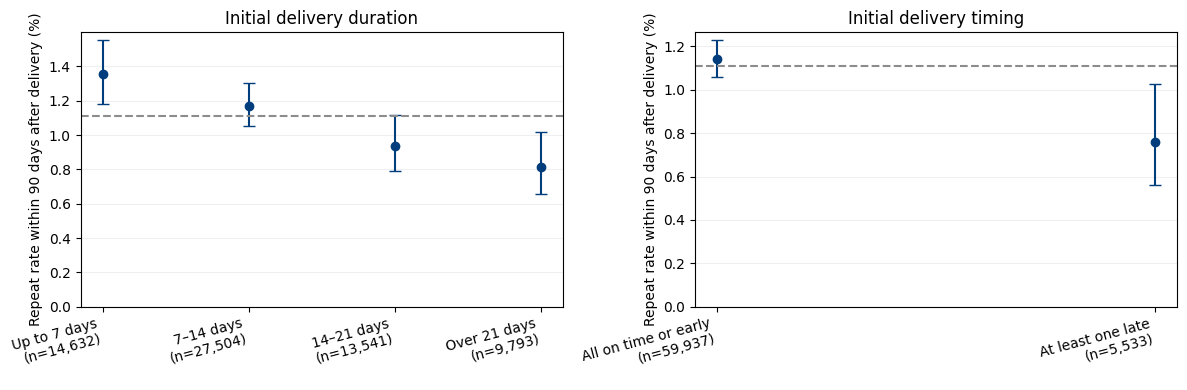

In [10]:
post_analysis = features.join(
    post_population[["repeat_after_delivery_90d", "prediction_at", "delivery_days",
                     "any_initial_order_late", "maximum_days_late"]],
    how="inner", validate="one_to_one",
).rename(columns={"repeat_after_delivery_90d": "repeat_90d"})
assert len(post_analysis)==len(post_population)
post_feature_rows = []
for feature in numeric_features + ["delivery_days", "any_initial_order_late", "maximum_days_late"]:
    pairs = post_analysis[[feature, "repeat_90d"]].dropna().astype(float)
    rho = pairs.rank().corr().iloc[0,1] if pairs[feature].nunique()>1 else np.nan
    post_feature_rows.append({
        "Feature": feature, "Customers": len(pairs), "Repeats": int(pairs["repeat_90d"].sum()),
        "Missing (%)": post_analysis[feature].isna().mean()*100, "Spearman rho": rho,
    })
post_associations = pd.DataFrame(post_feature_rows)
post_associations = post_associations.assign(
    magnitude=post_associations["Spearman rho"].abs()
).sort_values("magnitude", ascending=False).drop(columns="magnitude")
display(post_associations.head(10))
post_analysis["delivery_duration_band"] = pd.cut(
    post_analysis["delivery_days"], bins=[0, 7, 14, 21, np.inf],
    labels=["Up to 7 days", "7–14 days", "14–21 days", "Over 21 days"], include_lowest=True,
)
post_analysis["delivery_timing"] = post_analysis["any_initial_order_late"].map(
    {0.0: "All on time or early", 1.0: "At least one late"}
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, group, title in zip(
    axes, ["delivery_duration_band", "delivery_timing"],
    ["Initial delivery duration", "Initial delivery timing"]
):
    summary = rate_summary(post_analysis, group)
    display(summary)
    x = np.arange(len(summary))
    ax.errorbar(x, summary["repeat_rate_pct"], yerr=[
        summary["repeat_rate_pct"]-summary["lower_pct"], summary["upper_pct"]-summary["repeat_rate_pct"]
    ], fmt="o", color=BLUE, capsize=4)
    ax.axhline(post_analysis["repeat_90d"].mean()*100, color="#8C8C8C", linestyle="--")
    ax.set_xticks(x, [f"{name}\n(n={n:,})" for name,n in zip(summary.index,summary["customers"])], rotation=15, ha="right")
    ax.set(title=title, ylabel="Repeat rate within 90 days after delivery (%)", ylim=(0, None))
    ax.grid(axis="y", alpha=.2)
plt.tight_layout()
plt.show()
